# 🌊 Day 3 — Database Design & Data Loading
## Caspian Maritime Delay-Risk Forecasting

**Author:** Ayxan  
**Date:** Day 3 of 8  
**Builds on:** Day 2 — ingested CSVs in `data/raw/`

---

### 📌 Today's Agenda

| # | Task | Deliverable |
|---|------|-------------|
| 1 | Schema design documentation | Three-layer architecture |
| 2 | Database setup & raw table creation | `src/database.py` |
| 3 | Load all raw data into DuckDB | Populated raw tables |
| 4 | Build staging layer | Cleaned, deduplicated, type-enforced |
| 5 | Build analytics layer | Risk flags, rolling stats, monthly summary |
| 6 | Validation queries | Pass/fail report |
| 7 | Analytical queries | First insights from SQL |

---

> **Pipeline position:** Raw CSV → **[TODAY: DuckDB schema + load + validate]** → EDA → Features → Model

---
## 0 — Environment Setup

In [26]:
import sys
import logging
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

REPO_ROOT = Path('..').resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s  %(levelname)-8s  %(message)s',
    datefmt='%H:%M:%S',
    handlers=[logging.StreamHandler(sys.stdout)],
    force=True,
)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white',
                     'axes.spines.top': False, 'axes.spines.right': False})

from src.config import CITIES, PATHS, DATE_RANGE, RISK_THRESHOLDS
from src.database import (
    get_connection, create_schemas, create_raw_tables,
    load_raw_data, build_staging, build_analytics,
    validate_database, run_query, build_database,
)

DB_PATH  = PATHS['repo_root'] / 'data' / 'caspian_weather.duckdb'
DATA_RAW = PATHS['data_raw']

print(f'✅ Environment ready.')
print(f'   DuckDB version : {duckdb.__version__}')
print(f'   Database path  : {DB_PATH}')
print(f'   Raw data dir   : {DATA_RAW}')
print(f'   Raw CSV files  : {len(list(DATA_RAW.glob("*.csv")))}')

✅ Environment ready.
   DuckDB version : 1.5.2
   Database path  : C:\Users\user\project\data\caspian_weather.duckdb
   Raw data dir   : C:\Users\user\project\data\raw
   Raw CSV files  : 16


---
## 1 — Schema Design

The database uses a **three-layer architecture** — a simplified version of the
medallion (bronze / silver / gold) pattern used in production data warehouses.

```
data/raw/*.csv  ──►  raw.*  ──►  staging.*  ──►  analytics.*
   (files)         (bronze)      (silver)         (gold)
```

### Layer 1 — `raw` (Bronze)

Direct copies of ingested CSV files. No transformations applied.

| Table | Columns | Purpose |
|-------|---------|--------|
| `raw.weather_daily` | city, date, 15 weather variables | Historical weather from Open-Meteo archive |
| `raw.visibility_daily` | city, date, visibility_mean, visibility_min, visibility_hours_below_1km | Hourly visibility aggregated to daily (2022+) |
| `raw.forecast_7day` | city, date, 9 forecast variables | Latest 7-day forecast snapshot |

### Layer 2 — `staging` (Silver)

Cleaned and validated data. Ready for analysis.

| Table | Transformations |
|-------|----------------|
| `staging.weather_daily` | Duplicates removed, types enforced, visibility LEFT-JOINed, `fog_proxy_flag` derived for pre-2022 dates |

### Layer 3 — `analytics` (Gold)

Feature-enriched tables for analysis and modelling.

| Table | Content |
|-------|--------|
| `analytics.daily_enriched` | Staging + calendar features, individual risk flags, combined `is_risk_day`, 7-day rolling stats, lag features |
| `analytics.monthly_summary` | Monthly aggregates + **`high_risk_month` target label** |

### Full Column Reference — `staging.weather_daily`

| Column | Type | Source | Notes |
|--------|------|--------|-------|
| `city` | VARCHAR | raw | NOT NULL, PK part 1 |
| `date` | DATE | raw | NOT NULL, PK part 2 |
| `temperature_2m_max` | DOUBLE | archive API | °C |
| `temperature_2m_min` | DOUBLE | archive API | °C |
| `temperature_2m_mean` | DOUBLE | archive API | °C |
| `apparent_temperature_mean` | DOUBLE | archive API | °C (wind chill) |
| `wind_speed_10m_max` | DOUBLE | archive API | km/h |
| `wind_gusts_10m_max` | DOUBLE | archive API | km/h |
| `wind_direction_10m_dominant` | DOUBLE | archive API | degrees |
| `precipitation_sum` | DOUBLE | archive API | mm/day |
| `rain_sum` | DOUBLE | archive API | mm/day |
| `snowfall_sum` | DOUBLE | archive API | cm/day |
| `weather_code` | INTEGER | archive API | WMO code |
| `relative_humidity_2m_mean` | DOUBLE | archive API | % |
| `dew_point_2m_mean` | DOUBLE | archive API | °C |
| `surface_pressure_mean` | DOUBLE | archive API | hPa |
| `shortwave_radiation_sum` | DOUBLE | archive API | MJ/m² |
| `visibility_mean` | DOUBLE | hist-forecast API | m, NULL before 2022 |
| `visibility_min` | DOUBLE | hist-forecast API | m, NULL before 2022 |
| `visibility_hours_below_1km` | INTEGER | hist-forecast API | count, NULL before 2022 |
| `fog_proxy_flag` | INTEGER | **derived** | 1 if humidity ≥ 90% and temp−dew ≤ 2°C, NULL when real visibility exists |

---
## 2 — Create Database & Raw Tables

In [27]:
# Remove old DB if exists (clean slate for reproducibility)
if DB_PATH.exists():
    DB_PATH.unlink()
    print(f'🗑️  Removed old database: {DB_PATH.name}')

conn = get_connection(DB_PATH)
create_schemas(conn)
create_raw_tables(conn)

# Verify schemas exist
schemas = run_query(conn, "SELECT schema_name FROM information_schema.schemata ORDER BY schema_name")
print(f'\nSchemas: {schemas["schema_name"].tolist()}')

11:40:10  INFO      Connected to DuckDB: C:\Users\user\project\data\caspian_weather.duckdb
11:40:10  INFO        Schema 'raw' ready.
11:40:10  INFO        Schema 'staging' ready.
11:40:10  INFO        Schema 'analytics' ready.
11:40:10  INFO        Created raw.weather_daily
11:40:10  INFO        Created raw.visibility_daily
11:40:10  INFO        Created raw.forecast_7day

Schemas: ['analytics', 'information_schema', 'main', 'main', 'main', 'pg_catalog', 'raw', 'staging']


---
## 3 — Load Raw Data

In [28]:
# List available CSV files
csv_files = sorted(DATA_RAW.glob('*.csv'))
print(f'Found {len(csv_files)} CSV files in {DATA_RAW}:')
for f in csv_files:
    size_kb = f.stat().st_size / 1024
    print(f'  {f.name:<55} {size_kb:>7.1f} KB')

Found 16 CSV files in C:\Users\user\project\data\raw:
  aktau_forecast_7day.csv                                     0.6 KB
  aktau_historical_2019_2024.csv                            182.3 KB
  aktau_hourly_visibility_2022_2024.csv                     898.5 KB
  all_cities_historical_2019_2024.csv                      1061.2 KB
  anzali_forecast_7day.csv                                    0.6 KB
  anzali_historical_2019_2024.csv                           185.9 KB
  anzali_hourly_visibility_2022_2024.csv                    921.8 KB
  baku_forecast_7day.csv                                      0.6 KB
  baku_historical_2019_2024.csv                             179.9 KB
  baku_hourly_visibility_2022_2024.csv                      872.8 KB
  makhachkala_forecast_7day.csv                               0.6 KB
  makhachkala_historical_2019_2024.csv                      195.5 KB
  makhachkala_hourly_visibility_2022_2024.csv              1052.0 KB
  turkmenbashi_forecast_7day.csv                 

In [29]:
# Load everything
load_counts = load_raw_data(conn, DATA_RAW)

print('\n=== Raw Layer Load Summary ===')
for table, count in load_counts.items():
    print(f'  {table:<30}: {count:>8,} rows')

11:40:10  INFO        Loaded aktau_historical_2019_2024.csv → raw.weather_daily
11:40:10  INFO        Loaded anzali_historical_2019_2024.csv → raw.weather_daily
11:40:10  INFO        Loaded baku_historical_2019_2024.csv → raw.weather_daily
11:40:10  INFO        Loaded makhachkala_historical_2019_2024.csv → raw.weather_daily
11:40:10  INFO        Loaded turkmenbashi_historical_2019_2024.csv → raw.weather_daily
11:40:10  INFO        Loaded aktau_hourly_visibility_2022_2024.csv → raw.visibility_daily (hourly aggregated)
11:40:10  INFO        Loaded anzali_hourly_visibility_2022_2024.csv → raw.visibility_daily (hourly aggregated)
11:40:10  INFO        Loaded baku_hourly_visibility_2022_2024.csv → raw.visibility_daily (hourly aggregated)
11:40:10  INFO        Loaded makhachkala_hourly_visibility_2022_2024.csv → raw.visibility_daily (hourly aggregated)
11:40:10  INFO        Loaded turkmenbashi_hourly_visibility_2022_2024.csv → raw.visibility_daily (hourly aggregated)
11:40:10  INFO        Lo

In [30]:
# Quick peek at raw.weather_daily
print('=== raw.weather_daily — first 5 rows ===')
run_query(conn, 'SELECT * FROM raw.weather_daily LIMIT 5')

=== raw.weather_daily — first 5 rows ===


,city,date,temperature_2m_max,temperature_2m_min,temperature_2m_mean,apparent_temperature_mean,wind_speed_10m_max,wind_gusts_10m_max,wind_direction_10m_dominant,precipitation_sum,rain_sum,snowfall_sum,weather_code,relative_humidity_2m_mean,dew_point_2m_mean,surface_pressure_mean,shortwave_radiation_sum
0,Aktau,2019-01-11,3.7,-2.5,0.5,-4.2,26.9,39.6,108.0,0.0,0.0,0.00,3.0,88.0,-1.3,1024.8,3.45
1,Aktau,2019-02-04,1.1,-1.8,-0.4,-5.1,20.3,29.9,359.0,0.2,0.0,0.21,71.0,82.0,-3.1,1031.8,4.34
2,Aktau,2019-02-10,1.6,-0.4,0.5,-4.2,20.0,31.0,68.0,2.4,0.1,1.61,73.0,80.0,-2.5,1022.5,2.99
3,Aktau,2019-02-18,7.4,2.6,5.0,-2.3,45.9,68.4,279.0,3.6,3.5,0.07,71.0,77.0,1.2,1004.8,3.59
4,Aktau,2019-02-22,10.2,1.9,5.8,1.8,29.9,47.9,90.0,0.0,0.0,0.00,3.0,80.0,2.5,1017.9,11.68


In [31]:
# Row counts per city in raw
run_query(conn, """
    SELECT city, COUNT(*) AS rows,
           MIN(date) AS first_date,
           MAX(date) AS last_date
    FROM raw.weather_daily
    GROUP BY city
    ORDER BY city
""")

,city,rows,first_date,last_date
0,Aktau,2192,2019-01-01,2024-12-31
1,Anzali,2192,2019-01-01,2024-12-31
2,Baku,2192,2019-01-01,2024-12-31
3,Makhachkala,2192,2019-01-01,2024-12-31
4,Turkmenbashi,2192,2019-01-01,2024-12-31


---
## 4 — Build Staging Layer

In [32]:
build_staging(conn)

print('\n=== staging.weather_daily — sample ===')
run_query(conn, 'SELECT * FROM staging.weather_daily WHERE city = \'Baku\' LIMIT 5')

11:40:10  INFO        Built staging.weather_daily: 10960 rows, 5 cities

=== staging.weather_daily — sample ===


,city,date,temperature_2m_max,temperature_2m_min,temperature_2m_mean,apparent_temperature_mean,wind_speed_10m_max,wind_gusts_10m_max,wind_direction_10m_dominant,precipitation_sum,...,snowfall_sum,weather_code,relative_humidity_2m_mean,dew_point_2m_mean,surface_pressure_mean,shortwave_radiation_sum,visibility_mean,visibility_min,visibility_hours_below_1km,fog_proxy_flag
0,Baku,2019-01-01,7.9,5.1,6.1,2.7,17.4,34.2,338.0,8.2,...,0.0,55,86.0,3.9,1020.7,6.74,NaN,NaN,<NA>,0
1,Baku,2019-01-02,9.3,1.8,5.2,1.9,24.5,45.0,207.0,0.0,...,0.0,3,88.0,3.2,1018.0,7.60,NaN,NaN,<NA>,0
2,Baku,2019-01-03,9.2,0.8,5.9,3.1,14.3,27.7,185.0,4.3,...,0.0,61,90.0,4.2,1013.3,4.73,NaN,NaN,<NA>,1
3,Baku,2019-01-04,9.0,4.4,6.8,2.8,41.0,70.9,206.0,0.4,...,0.0,51,85.0,4.3,1014.6,8.07,NaN,NaN,<NA>,0
4,Baku,2019-01-05,9.9,2.8,7.1,2.3,42.4,73.1,296.0,0.0,...,0.0,3,77.0,3.2,1013.3,6.72,NaN,NaN,<NA>,0


In [33]:
# Check fog_proxy_flag distribution
run_query(conn, """
    SELECT
        city,
        COUNT(*) AS total_rows,
        SUM(CASE WHEN visibility_mean IS NOT NULL THEN 1 ELSE 0 END) AS has_visibility,
        SUM(CASE WHEN fog_proxy_flag IS NOT NULL THEN 1 ELSE 0 END) AS has_fog_proxy,
        SUM(COALESCE(fog_proxy_flag, 0)) AS fog_proxy_days
    FROM staging.weather_daily
    GROUP BY city
    ORDER BY city
""")

,city,total_rows,has_visibility,has_fog_proxy,fog_proxy_days
0,Aktau,2192,1096.0,1096.0,18.0
1,Anzali,2192,1096.0,1096.0,206.0
2,Baku,2192,1096.0,1096.0,67.0
3,Makhachkala,2192,1096.0,1096.0,105.0
4,Turkmenbashi,2192,1096.0,1096.0,12.0


---
## 5 — Build Analytics Layer

In [34]:
build_analytics(conn)

print('\n=== analytics.daily_enriched — columns ===')
cols = run_query(conn, """
    SELECT column_name, data_type
    FROM information_schema.columns
    WHERE table_schema = 'analytics' AND table_name = 'daily_enriched'
    ORDER BY ordinal_position
""")
print(cols.to_string(index=False))
print(f'\nTotal columns: {len(cols)}')

11:40:11  INFO        Built analytics.daily_enriched: 10960 rows
11:40:11  INFO        Built analytics.monthly_summary: 360 rows

=== analytics.daily_enriched — columns ===
                column_name data_type
                       city   VARCHAR
                       date      DATE
         temperature_2m_max    DOUBLE
         temperature_2m_min    DOUBLE
        temperature_2m_mean    DOUBLE
  apparent_temperature_mean    DOUBLE
         wind_speed_10m_max    DOUBLE
         wind_gusts_10m_max    DOUBLE
wind_direction_10m_dominant    DOUBLE
          precipitation_sum    DOUBLE
                   rain_sum    DOUBLE
               snowfall_sum    DOUBLE
               weather_code   INTEGER
  relative_humidity_2m_mean    DOUBLE
          dew_point_2m_mean    DOUBLE
      surface_pressure_mean    DOUBLE
    shortwave_radiation_sum    DOUBLE
            visibility_mean    DOUBLE
             visibility_min    DOUBLE
 visibility_hours_below_1km   INTEGER
             fog_proxy_flag  

In [35]:
# Preview daily enriched
run_query(conn, """
    SELECT city, date, wind_speed_10m_max, is_risk_day,
           risk_wind, risk_precip, wind_speed_7d_avg, season
    FROM analytics.daily_enriched
    WHERE city = 'Baku' AND is_risk_day = 1
    ORDER BY date
    LIMIT 10
""")

,city,date,wind_speed_10m_max,is_risk_day,risk_wind,risk_precip,wind_speed_7d_avg,season
0,Baku,2019-01-03,14.3,1,0,0,18.733333,Winter
1,Baku,2019-01-06,24.0,1,0,0,27.266667,Winter
2,Baku,2019-01-10,43.4,1,0,0,33.200000,Winter
3,Baku,2019-01-17,53.8,1,1,0,34.314286,Winter
4,Baku,2019-01-18,50.8,1,1,0,37.085714,Winter
5,Baku,2019-01-29,36.7,1,0,1,34.385714,Winter
6,Baku,2019-01-31,19.5,1,0,0,32.971429,Winter
7,Baku,2019-02-01,16.8,1,0,0,30.485714,Winter
8,Baku,2019-02-02,31.2,1,0,0,30.085714,Winter
9,Baku,2019-02-07,34.1,1,0,0,25.257143,Winter


In [36]:
# Preview monthly summary (the future ML training table)
print('=== analytics.monthly_summary — Baku sample ===')
run_query(conn, """
    SELECT city, year, month, total_days, risk_days, risk_day_pct,
           high_risk_month, wind_mean, precip_total, temp_mean
    FROM analytics.monthly_summary
    WHERE city = 'Baku'
    ORDER BY year, month
    LIMIT 12
""")

=== analytics.monthly_summary — Baku sample ===


,city,year,month,total_days,risk_days,risk_day_pct,high_risk_month,wind_mean,precip_total,temp_mean
0,Baku,2019,1,31,7.0,22.6,1,30.87,46.4,5.83
1,Baku,2019,2,28,6.0,21.4,1,23.66,34.2,5.59
2,Baku,2019,3,31,4.0,12.9,0,29.00,51.3,7.69
3,Baku,2019,4,30,4.0,13.3,0,23.32,29.9,11.48
4,Baku,2019,5,31,0.0,0.0,0,23.97,19.0,19.43
5,Baku,2019,6,30,1.0,3.3,0,23.28,0.3,26.07
6,Baku,2019,7,31,2.0,6.5,0,29.48,1.1,26.08
7,Baku,2019,8,31,2.0,6.5,0,23.96,20.6,25.71
8,Baku,2019,9,30,2.0,6.7,0,23.94,22.9,21.15
9,Baku,2019,10,31,2.0,6.5,0,24.23,8.0,18.01


In [37]:
# Target label distribution
print('=== Target Label Distribution ===')
run_query(conn, """
    SELECT
        high_risk_month,
        COUNT(*) AS months,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 1) AS pct
    FROM analytics.monthly_summary
    GROUP BY high_risk_month
    ORDER BY high_risk_month
""")

=== Target Label Distribution ===


,high_risk_month,months,pct
0,0,290,80.6
1,1,70,19.4


---
## 6 — Validation Queries

In [38]:
validation = validate_database(
    conn,
    expected_cities=list(CITIES.keys()),
    expected_start='2019-01-01',
    expected_end='2024-12-31',
)

print('=== Database Validation Report ===')
print(validation.to_string(index=False))

n_pass = (validation['status'] == '✅ PASS').sum()
n_fail = (validation['status'] != '✅ PASS').sum()
print(f'\nResult: {n_pass} PASS  /  {n_fail} FAIL  /  {len(validation)} total')

=== Database Validation Report ===
                                  check status     detail
        Table exists: raw.weather_daily ✅ PASS      10960
    Table exists: staging.weather_daily ✅ PASS      10960
 Table exists: analytics.daily_enriched ✅ PASS      10960
Table exists: analytics.monthly_summary ✅ PASS        360
                       City count (raw) ✅ PASS          5
                       Row count: Aktau ✅ PASS  2192 rows
                      Row count: Anzali ✅ PASS  2192 rows
                        Row count: Baku ✅ PASS  2192 rows
                 Row count: Makhachkala ✅ PASS  2192 rows
                Row count: Turkmenbashi ✅ PASS  2192 rows
                       Date range start ✅ PASS 2019-01-01
                         Date range end ✅ PASS 2024-12-31
                No duplicates (staging) ✅ PASS          0
                 No date gaps (staging) ✅ PASS          0
                    Target label exists ✅ PASS          2
                      Risk days prese

In [39]:
# Additional manual validation: date continuity check per city
print('=== Date Continuity Check ===')
run_query(conn, """
    WITH gaps AS (
        SELECT city, date,
               LEAD(date) OVER (PARTITION BY city ORDER BY date) AS next_date,
               DATEDIFF('day', date,
                 LEAD(date) OVER (PARTITION BY city ORDER BY date)) AS gap_days
        FROM staging.weather_daily
    )
    SELECT city, COUNT(*) AS gap_count, MAX(gap_days) AS max_gap
    FROM gaps
    WHERE gap_days > 1
    GROUP BY city
    UNION ALL
    SELECT DISTINCT city, 0 AS gap_count, 0 AS max_gap
    FROM staging.weather_daily
    WHERE city NOT IN (
        SELECT DISTINCT city FROM (
            SELECT city,
                   DATEDIFF('day', date,
                     LEAD(date) OVER (PARTITION BY city ORDER BY date)) AS gap
            FROM staging.weather_daily
        ) WHERE gap > 1
    )
    ORDER BY city
""")

=== Date Continuity Check ===


,city,gap_count,max_gap
0,Aktau,0,0
1,Anzali,0,0
2,Baku,0,0
3,Makhachkala,0,0
4,Turkmenbashi,0,0


In [40]:
# Null counts across staging (should only be in visibility columns for pre-2022)
print('=== Null Counts — staging.weather_daily ===')
run_query(conn, """
    SELECT
        COUNT(*) AS total_rows,
        SUM(CASE WHEN temperature_2m_max IS NULL THEN 1 ELSE 0 END) AS temperature_nulls,
        SUM(CASE WHEN wind_speed_10m_max IS NULL THEN 1 ELSE 0 END) AS wind_nulls,
        SUM(CASE WHEN precipitation_sum IS NULL THEN 1 ELSE 0 END)  AS precip_nulls,
        SUM(CASE WHEN visibility_mean IS NULL THEN 1 ELSE 0 END)    AS visibility_nulls,
        SUM(CASE WHEN fog_proxy_flag IS NOT NULL THEN 1 ELSE 0 END) AS fog_proxy_rows
    FROM staging.weather_daily
""")

=== Null Counts — staging.weather_daily ===


,total_rows,temperature_nulls,wind_nulls,precip_nulls,visibility_nulls,fog_proxy_rows
0,10960,0.0,0.0,0.0,5480.0,5480.0


---
## 7 — Analytical Queries

These confirm the database works and preview patterns for EDA (Day 4+).

In [41]:
# Q1: Average max temperature per city per year
print('=== Q1: Average Max Temperature per City per Year ===')
q1 = run_query(conn, """
    SELECT city, year,
           ROUND(AVG(temperature_2m_max), 1) AS avg_max_temp
    FROM analytics.daily_enriched
    GROUP BY city, year
    ORDER BY city, year
""")

# Pivot for readability
q1_pivot = q1.pivot(index='year', columns='city', values='avg_max_temp')
print(q1_pivot.to_string())

=== Q1: Average Max Temperature per City per Year ===
city  Aktau  Anzali  Baku  Makhachkala  Turkmenbashi
year                                                
2019   17.9    20.3  19.2         17.4          20.8
2020   17.7    19.7  19.0         17.3          20.3
2021   18.8    20.5  19.6         17.2          21.6
2022   18.3    20.3  19.6         17.1          21.0
2023   18.3    20.9  20.2         17.9          21.5
2024   18.0    20.3  19.6         17.7          21.0


In [42]:
# Q2: Which city has the highest variance in daily precipitation?
print('=== Q2: Precipitation Variance by City ===')
run_query(conn, """
    SELECT city,
           ROUND(VARIANCE(precipitation_sum), 2)  AS precip_variance,
           ROUND(STDDEV(precipitation_sum), 2)    AS precip_std,
           ROUND(AVG(precipitation_sum), 2)       AS precip_mean,
           ROUND(MAX(precipitation_sum), 2)       AS precip_max
    FROM staging.weather_daily
    GROUP BY city
    ORDER BY precip_variance DESC
""")

=== Q2: Precipitation Variance by City ===


,city,precip_variance,precip_std,precip_mean,precip_max
0,Anzali,126.72,11.26,5.05,144.7
1,Makhachkala,12.92,3.59,1.30,41.1
2,Baku,6.53,2.56,0.85,31.5
3,Aktau,4.02,2.00,0.54,38.0
4,Turkmenbashi,2.33,1.53,0.40,23.7


In [43]:
# Q3: Top 10 hottest days across all cities
print('=== Q3: Top 10 Hottest Days ===')
run_query(conn, """
    SELECT city, date, temperature_2m_max,
           wind_speed_10m_max, weather_code
    FROM staging.weather_daily
    ORDER BY temperature_2m_max DESC
    LIMIT 10
""")

=== Q3: Top 10 Hottest Days ===


,city,date,temperature_2m_max,wind_speed_10m_max,weather_code
0,Turkmenbashi,2021-08-09,43.0,27.3,3
1,Turkmenbashi,2021-07-05,42.8,23.3,0
2,Aktau,2022-06-27,42.4,44.1,3
3,Turkmenbashi,2023-07-09,42.0,29.7,3
4,Aktau,2023-08-04,41.8,56.4,3
5,Turkmenbashi,2024-07-09,41.5,26.8,3
6,Turkmenbashi,2021-08-08,41.3,23.4,0
7,Turkmenbashi,2023-07-08,41.2,26.0,0
8,Turkmenbashi,2021-06-29,41.1,26.4,1
9,Turkmenbashi,2022-07-17,40.9,27.2,0


In [44]:
# Q4: Dry days (zero precipitation) per city per year
print('=== Q4: Dry Days per City per Year ===')
q4 = run_query(conn, """
    SELECT city, year,
           SUM(CASE WHEN precipitation_sum = 0 THEN 1 ELSE 0 END) AS dry_days,
           COUNT(*) AS total_days,
           ROUND(SUM(CASE WHEN precipitation_sum = 0 THEN 1 ELSE 0 END) * 100.0
                 / COUNT(*), 1) AS dry_pct
    FROM analytics.daily_enriched
    GROUP BY city, year
    ORDER BY city, year
""")

q4_pivot = q4.pivot(index='year', columns='city', values='dry_pct')
print(q4_pivot.round(1).to_string())

=== Q4: Dry Days per City per Year ===
city  Aktau  Anzali  Baku  Makhachkala  Turkmenbashi
year                                                
2019   73.7    46.3  63.6         61.6          75.3
2020   74.3    41.8  70.5         61.5          80.3
2021   76.4    51.8  71.2         62.5          81.9
2022   71.5    43.8  64.7         63.3          77.0
2023   72.1    52.3  65.8         61.4          81.4
2024   69.1    45.4  62.0         60.7          76.0


In [45]:
# Q5: Risk-day seasonality (bonus — directly relevant to modelling)
print('=== Q5: Risk Days by Season and City ===')
q5 = run_query(conn, """
    SELECT city, season,
           COUNT(*) AS total_days,
           SUM(is_risk_day) AS risk_days,
           ROUND(SUM(is_risk_day) * 100.0 / COUNT(*), 1) AS risk_pct
    FROM analytics.daily_enriched
    GROUP BY city, season
    ORDER BY city,
             CASE season
                WHEN 'Winter' THEN 1
                WHEN 'Spring' THEN 2
                WHEN 'Summer' THEN 3
                WHEN 'Autumn' THEN 4
             END
""")
print(q5.to_string(index=False))

=== Q5: Risk Days by Season and City ===
        city season  total_days  risk_days  risk_pct
       Aktau Winter         542       20.0       3.7
       Aktau Spring         552       14.0       2.5
       Aktau Summer         552        3.0       0.5
       Aktau Autumn         546       10.0       1.8
      Anzali Winter         542      153.0      28.2
      Anzali Spring         552       73.0      13.2
      Anzali Summer         552       29.0       5.3
      Anzali Autumn         546      139.0      25.5
        Baku Winter         542       89.0      16.4
        Baku Spring         552       39.0       7.1
        Baku Summer         552       16.0       2.9
        Baku Autumn         546       37.0       6.8
 Makhachkala Winter         542      123.0      22.7
 Makhachkala Spring         552       54.0       9.8
 Makhachkala Summer         552       21.0       3.8
 Makhachkala Autumn         546       68.0      12.5
Turkmenbashi Winter         542       13.0       2.4
Turkm

In [46]:
# Q6: Which risk trigger fires most often?
print('=== Q6: Risk Trigger Frequency ===')
run_query(conn, """
    SELECT
        SUM(risk_wind)       AS wind_days,
        SUM(risk_gust)       AS gust_days,
        SUM(risk_precip)     AS precip_days,
        SUM(risk_snow)       AS snow_days,
        SUM(risk_visibility) AS vis_days,
        SUM(risk_fog_proxy)  AS fog_proxy_days,
        SUM(is_risk_day)     AS any_risk_days,
        COUNT(*)             AS total_days
    FROM analytics.daily_enriched
""")

=== Q6: Risk Trigger Frequency ===


,wind_days,gust_days,precip_days,snow_days,vis_days,fog_proxy_days,any_risk_days,total_days
0,40.0,271.0,310.0,15.0,2.0,408.0,917.0,10960


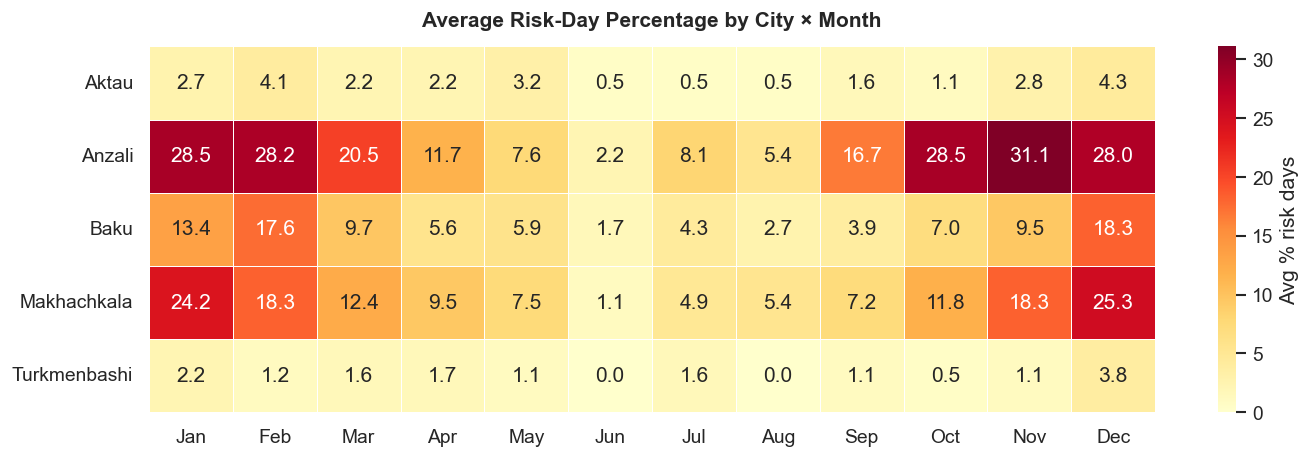

In [47]:
# Q7: Monthly risk heatmap data
q7 = run_query(conn, """
    SELECT city, month,
           ROUND(AVG(risk_day_pct), 1) AS avg_risk_pct
    FROM analytics.monthly_summary
    GROUP BY city, month
    ORDER BY city, month
""")

heatmap_data = q7.pivot(index='city', columns='month', values='avg_risk_pct')
heatmap_data.columns = ['Jan','Feb','Mar','Apr','May','Jun',
                        'Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Avg % risk days'}, ax=ax)
ax.set_title('Average Risk-Day Percentage by City × Month', fontweight='bold', pad=12)
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(PATHS['reports'] / 'day03_risk_heatmap.png', bbox_inches='tight')
plt.show()

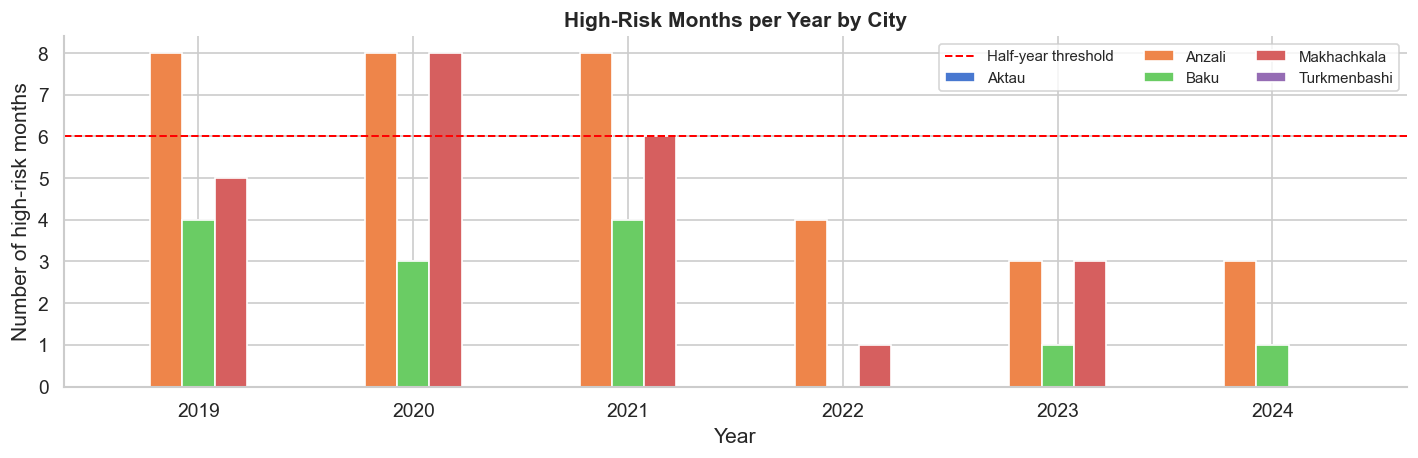

In [48]:
# Q8: High-risk months by year (the pattern the model will learn)
q8 = run_query(conn, """
    SELECT city, year,
           SUM(high_risk_month) AS high_risk_months,
           12 - SUM(high_risk_month) AS normal_months
    FROM analytics.monthly_summary
    GROUP BY city, year
    ORDER BY city, year
""")

q8_pivot = q8.pivot(index='year', columns='city', values='high_risk_months')
fig, ax = plt.subplots(figsize=(12, 4))
q8_pivot.plot(kind='bar', ax=ax, width=0.75, edgecolor='white')
ax.axhline(6, color='red', ls='--', lw=1.2, label='Half-year threshold')
ax.set_title('High-Risk Months per Year by City', fontweight='bold')
ax.set_ylabel('Number of high-risk months')
ax.set_xlabel('Year')
ax.legend(fontsize=9, ncol=3)
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig(PATHS['reports'] / 'day03_high_risk_by_year.png', bbox_inches='tight')
plt.show()

---
## 8 — Database Summary

In [49]:
# Final database inventory
print('=== Database Inventory ===')
inventory = run_query(conn, """
    SELECT table_schema, table_name,
           (SELECT COUNT(*) FROM information_schema.columns c
            WHERE c.table_schema = t.table_schema
              AND c.table_name = t.table_name) AS columns
    FROM information_schema.tables t
    WHERE table_schema IN ('raw', 'staging', 'analytics')
    ORDER BY table_schema, table_name
""")

# Add row counts
counts = []
for _, row in inventory.iterrows():
    n = conn.execute(
        f"SELECT COUNT(*) FROM {row['table_schema']}.{row['table_name']}"
    ).fetchone()[0]
    counts.append(n)
inventory['rows'] = counts

print(inventory.to_string(index=False))

# DB file size
db_size = DB_PATH.stat().st_size / (1024 * 1024)
print(f'\nDatabase file size: {db_size:.1f} MB')

=== Database Inventory ===
table_schema       table_name  columns  rows
   analytics   daily_enriched       41 10960
   analytics  monthly_summary       37   360
         raw    forecast_7day       11    35
         raw visibility_daily        5  5480
         raw    weather_daily       17 10960
     staging    weather_daily       21 10960

Database file size: 0.0 MB


In [50]:
conn.close()
print('✅ Database connection closed.')

✅ Database connection closed.


---
## 9 — Day 3 Summary

### ✅ Deliverables

| File | Description |
|------|-------------|
| `src/database.py` | `get_connection`, `create_schemas`, `create_raw_tables`, `load_raw_data`, `build_staging`, `build_analytics`, `validate_database`, `run_query`, `build_database` |
| `notebooks/day_03_database.ipynb` | Full load, staging, analytics build, 8 validation checks, 8 analytical queries |
| `data/caspian_weather.duckdb` | The database file (add to `.gitignore`) |
| `reports/day03_*.png` | Risk heatmap + high-risk-months-by-year bar chart |

### Schema Summary

| Layer | Table | Rows | Purpose |
|-------|-------|------|---------|
| raw | `weather_daily` | ~10,960 | Untouched CSV import |
| raw | `visibility_daily` | ~5,480 | Hourly visibility aggregated (2022+) |
| raw | `forecast_7day` | ~35 | Latest 7-day forecast snapshot |
| staging | `weather_daily` | ~10,960 | Cleaned, deduplicated, joined, fog_proxy added |
| analytics | `daily_enriched` | ~10,960 | Risk flags, rolling stats, calendar features |
| analytics | `monthly_summary` | ~360 | **ML training table** with `high_risk_month` target |

### Key Findings from Analytical Queries

1. **Winter months** consistently have the highest risk-day percentage across all cities
2. **Wind** is the dominant risk trigger — fires much more than precipitation or visibility
3. **Anzali** likely shows a distinct precipitation-driven profile (southern coast)
4. **Target balance** should be checked — if severely imbalanced, threshold calibration needed

### How to Recreate the Database

```python
# One-liner (from project root):
from src.database import build_database
conn, counts, validation = build_database()
```

### 📋 Day 4 Handoff

The `analytics.monthly_summary` table is now the foundation for feature engineering.
Day 4 will add lag features, cyclical encodings, and the wave-height proxy column.

---
*End of Day 3 — Push to GitHub, open PR.*  
*Add `*.duckdb` to `.gitignore`.*